In [1]:
import os
import hashlib
from pathlib import Path
from collections import Counter

# Adjust this path to wherever your PlantVillage folder lives
# Kaggle: '/kaggle/input/plantvillage-dataset/...'
# Colab: '/content/drive/MyDrive/Neural AI/CropScan/PlantVillage'
DATA_ROOT = Path("PlantVillage")  # <-- UPDATE THIS to your actual path

print(f"Data root exists: {DATA_ROOT.exists()}")
print(f"Contents: {os.listdir(DATA_ROOT)}")

Data root exists: True
Contents: ['Tomato__Tomato_YellowLeaf__Curl_Virus', 'Pepper__bell___Bacterial_spot', 'Tomato__Target_Spot', 'Tomato_Bacterial_spot', 'Potato___Early_blight', '.ipynb_checkpoints', 'Tomato__Tomato_mosaic_virus', 'Tomato_Late_blight', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Leaf_Mold', 'Tomato_healthy', 'Tomato_Early_blight', 'Potato___Late_blight', 'PlantVillage', 'Tomato_Septoria_leaf_spot', 'Pepper__bell___healthy', 'Potato___healthy']


In [2]:
class_dirs = sorted([d for d in DATA_ROOT.iterdir() if d.is_dir()])

print(f"Total class folders found: {len(class_dirs)}\n")
print(f"{'Class':<45} {'Images':>6}")
print("-" * 55)

total = 0
class_counts = {}
for d in class_dirs:
    imgs = [f for f in d.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    class_counts[d.name] = len(imgs)
    total += len(imgs)
    print(f"{d.name:<45} {len(imgs):>6}")

print("-" * 55)
print(f"{'TOTAL':<45} {total:>6}")
print(f"\nExpected ~54,306 images across 38 classes")

Total class folders found: 17

Class                                         Images
-------------------------------------------------------
.ipynb_checkpoints                                 0
Pepper__bell___Bacterial_spot                    997
Pepper__bell___healthy                          1478
PlantVillage                                       0
Potato___Early_blight                           1000
Potato___Late_blight                            1000
Potato___healthy                                 152
Tomato_Bacterial_spot                           2127
Tomato_Early_blight                             1000
Tomato_Late_blight                              1909
Tomato_Leaf_Mold                                 952
Tomato_Septoria_leaf_spot                       1771
Tomato_Spider_mites_Two_spotted_spider_mite     1676
Tomato__Target_Spot                             1404
Tomato__Tomato_YellowLeaf__Curl_Virus           3208
Tomato__Tomato_mosaic_virus                      373
Tomato_healt

In [3]:
# Check if there's a nested PlantVillage folder (common with this dataset)
nested = DATA_ROOT / "PlantVillage"
if nested.exists() and nested.is_dir():
    nested_dirs = sorted([d for d in nested.iterdir() if d.is_dir()])
    print(f"⚠️  Found NESTED 'PlantVillage' subfolder with {len(nested_dirs)} class dirs!")
    print("   This might be the actual data root. Listing its contents:\n")
    for d in nested_dirs[:10]:
        imgs = [f for f in d.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
        print(f"   {d.name:<45} {len(imgs):>6}")
    if len(nested_dirs) > 10:
        print(f"   ... and {len(nested_dirs) - 10} more folders")
    
    # If the nested one has MORE class folders, that's probably the real root
    if len(nested_dirs) > len(class_dirs) - 1:  # -1 to exclude the nested folder itself
        print(f"\n✅ RECOMMENDATION: Use the nested path instead:")
        print(f'   DATA_ROOT = Path("{nested}")')
else:
    print("✅ No nested PlantVillage folder — structure looks clean.")

⚠️  Found NESTED 'PlantVillage' subfolder with 16 class dirs!
   This might be the actual data root. Listing its contents:

   .ipynb_checkpoints                                 0
   Pepper__bell___Bacterial_spot                    997
   Pepper__bell___healthy                          1478
   Potato___Early_blight                           1000
   Potato___Late_blight                            1000
   Potato___healthy                                 152
   Tomato_Bacterial_spot                           2127
   Tomato_Early_blight                             1000
   Tomato_Late_blight                              1909
   Tomato_Leaf_Mold                                 952
   ... and 6 more folders


In [5]:
import random

def file_hash(filepath):
    """MD5 hash of file contents."""
    h = hashlib.md5()
    with open(filepath, 'rb') as f:
        h.update(f.read())
    return h.hexdigest()

# Sample up to 200 images per class to check for duplicates
all_hashes = {}
duplicates = []

for d in class_dirs:
    if not d.is_dir() or d.name == "PlantVillage":
        continue
    imgs = [f for f in d.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    sample = imgs if len(imgs) <= 200 else random.sample(imgs, 200)
    
    for img_path in sample:
        h = file_hash(img_path)
        if h in all_hashes:
            duplicates.append((str(img_path), str(all_hashes[h])))
        else:
            all_hashes[h] = img_path

print(f"Checked {len(all_hashes) + len(duplicates)} images (sampled)")
if duplicates:
    print(f"⚠️  Found {len(duplicates)} duplicate images:")
    for dup, orig in duplicates[:5]:
        print(f"   DUP:  {dup}")
        print(f"   ORIG: {orig}\n")
else:
    print("✅ No duplicate images found in sample.")

Checked 2952 images (sampled)
✅ No duplicate images found in sample.


In [6]:
import torch
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
import numpy as np

# Exclude junk folders
EXCLUDE = {'.ipynb_checkpoints', 'PlantVillage'}
valid_classes = sorted([d.name for d in DATA_ROOT.iterdir() 
                        if d.is_dir() and d.name not in EXCLUDE])

print(f"✅ {len(valid_classes)} valid classes:")
for i, c in enumerate(valid_classes):
    print(f"  {i:>2}. {c}")

✅ 15 valid classes:
   0. Pepper__bell___Bacterial_spot
   1. Pepper__bell___healthy
   2. Potato___Early_blight
   3. Potato___Late_blight
   4. Potato___healthy
   5. Tomato_Bacterial_spot
   6. Tomato_Early_blight
   7. Tomato_Late_blight
   8. Tomato_Leaf_Mold
   9. Tomato_Septoria_leaf_spot
  10. Tomato_Spider_mites_Two_spotted_spider_mite
  11. Tomato__Target_Spot
  12. Tomato__Tomato_YellowLeaf__Curl_Virus
  13. Tomato__Tomato_mosaic_virus
  14. Tomato_healthy


In [7]:
# ImageNet stats (since we'll use pretrained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224

train_transform = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("✅ Transforms defined")
print(f"   Train: RandomResizedCrop → Flip → Rotate → ColorJitter → Normalize")
print(f"   Val/Test: Resize(256) → CenterCrop(224) → Normalize")

✅ Transforms defined
   Train: RandomResizedCrop → Flip → Rotate → ColorJitter → Normalize
   Val/Test: Resize(256) → CenterCrop(224) → Normalize


In [8]:
import shutil, tempfile

# ImageFolder needs a clean directory — symlink valid classes only
CLEAN_ROOT = Path("PlantVillage_clean")
if CLEAN_ROOT.exists():
    shutil.rmtree(CLEAN_ROOT)
CLEAN_ROOT.mkdir()

for cls in valid_classes:
    os.symlink((DATA_ROOT / cls).resolve(), CLEAN_ROOT / cls)

# Load full dataset with basic transform first (just for splitting)
full_dataset = ImageFolder(str(CLEAN_ROOT), transform=val_transform)

print(f"Total samples: {len(full_dataset)}")
print(f"Classes: {len(full_dataset.classes)}")
print(f"Class-to-idx mapping:")
for cls, idx in sorted(full_dataset.class_to_idx.items(), key=lambda x: x[1]):
    print(f"  {idx:>2}: {cls}")

Total samples: 20638
Classes: 15
Class-to-idx mapping:
   0: Pepper__bell___Bacterial_spot
   1: Pepper__bell___healthy
   2: Potato___Early_blight
   3: Potato___Late_blight
   4: Potato___healthy
   5: Tomato_Bacterial_spot
   6: Tomato_Early_blight
   7: Tomato_Late_blight
   8: Tomato_Leaf_Mold
   9: Tomato_Septoria_leaf_spot
  10: Tomato_Spider_mites_Two_spotted_spider_mite
  11: Tomato__Target_Spot
  12: Tomato__Tomato_YellowLeaf__Curl_Virus
  13: Tomato__Tomato_mosaic_virus
  14: Tomato_healthy


In [9]:
from sklearn.model_selection import train_test_split

# Get all targets for stratified split
targets = [s[1] for s in full_dataset.samples]
indices = list(range(len(full_dataset)))

# First split: 70% train, 30% temp
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=[targets[i] for i in indices], random_state=42
)

# Second split: 50/50 of the 30% → 15% val, 15% test
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_targets, random_state=42
)

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")
print(f"Total: {len(train_idx) + len(val_idx) + len(test_idx)}")

# Quick check: class distribution in train
train_targets = [targets[i] for i in train_idx]
dist = Counter(train_targets)
print(f"\nTrain class distribution (min → max):")
for idx in sorted(dist, key=dist.get):
    print(f"  {full_dataset.classes[idx]:<50} {dist[idx]:>5}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  Fi

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  Fi

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Train: 14446 | Val: 3096 | Test: 3096
Total: 20638

Train class distribution (min → max):
  Potato___healthy                                     106
  Tomato__Tomato_mosaic_virus                          261
  Tomato_Leaf_Mold                                     666
  Pepper__bell___Bacterial_spot                        698
  Potato___Late_blight                                 700
  Tomato_Early_blight                                  700
  Potato___Early_blight                                700
  Tomato__Target_Spot                                  983
  Pepper__bell___healthy                              1035
  Tomato_healthy                                      1114
  Tomato_Spider_mites_Two_spotted_spider_mite         1173
  Tomato_Septoria_leaf_spot                           1240
  Tomato_Late_blight                                  1336
  Tomato_Bacterial_spot                               1489
  Tomato__Tomato_YellowLeaf__Curl_Virus               2245


In [10]:
from torch.utils.data import Subset

# Create subsets
train_dataset = Subset(ImageFolder(str(CLEAN_ROOT), transform=train_transform), train_idx)
val_dataset   = Subset(full_dataset, val_idx)   # already has val_transform
test_dataset  = Subset(full_dataset, test_idx)

# Weighted sampler to handle class imbalance (especially Potato___healthy @ 152)
train_targets_tensor = [targets[i] for i in train_idx]
class_counts_train = Counter(train_targets_tensor)
class_weights = {cls: 1.0 / count for cls, count in class_counts_train.items()}
sample_weights = [class_weights[t] for t in train_targets_tensor]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Sanity check — grab one batch
imgs, labels = next(iter(train_loader))
print(f"✅ DataLoaders ready")
print(f"   Batch shape: {imgs.shape}  (B, C, H, W)")
print(f"   Labels: {labels[:8].tolist()}...")
print(f"   Train batches/epoch: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

✅ DataLoaders ready
   Batch shape: torch.Size([32, 3, 224, 224])  (B, C, H, W)
   Labels: [10, 3, 7, 0, 9, 1, 7, 6]...
   Train batches/epoch: 452
   Val batches: 97
   Test batches: 97


In [11]:
import torchvision.models as models
import torch.nn as nn

NUM_CLASSES = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def build_efficientnet_b0(num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    # Freeze backbone initially
    for param in model.features.parameters():
        param.requires_grad = False
    # Replace classifier head
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.classifier[1].in_features, num_classes)
    )
    return model

def build_mobilenet_v2(num_classes):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V2)
    # Freeze backbone initially
    for param in model.features.parameters():
        param.requires_grad = False
    # Replace classifier head
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.classifier[1].in_features, num_classes)
    )
    return model

# Build both
eff_model = build_efficientnet_b0(NUM_CLASSES).to(device)
mob_model = build_mobilenet_v2(NUM_CLASSES).to(device)

# Quick param count
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

for name, m in [("EfficientNet-B0", eff_model), ("MobileNetV2", mob_model)]:
    total, trainable = count_params(m)
    print(f"\n{name}:")
    print(f"  Total params:     {total:>10,}")
    print(f"  Trainable params: {trainable:>10,}")
    print(f"  Frozen params:    {total - trainable:>10,}")

Using device: cuda

EfficientNet-B0:
  Total params:      4,026,763
  Trainable params:     19,215
  Frozen params:     4,007,548

MobileNetV2:
  Total params:      2,243,087
  Trainable params:     19,215
  Frozen params:     2,223,872


In [12]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time, copy

def train_model(model, train_loader, val_loader, model_name, 
                epochs_frozen=5, epochs_unfrozen=10, lr_frozen=1e-3, lr_unfrozen=1e-4):
    """
    Two-phase training:
      Phase 1: Train only the classifier head (backbone frozen)
      Phase 2: Unfreeze backbone, fine-tune everything with lower LR
    """
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "epoch_time": []}
    best_val_acc = 0.0
    best_model_wts = None
    
    criterion = nn.CrossEntropyLoss()
    
    for phase, (epochs, lr, frozen) in enumerate([
        (epochs_frozen, lr_frozen, True),
        (epochs_unfrozen, lr_unfrozen, False)
    ]):
        phase_name = "FROZEN" if frozen else "UNFROZEN"
        print(f"\n{'='*60}")
        print(f"  {model_name} — Phase {phase+1}: {phase_name} (lr={lr}, {epochs} epochs)")
        print(f"{'='*60}")
        
        if not frozen:
            # Unfreeze everything
            for param in model.parameters():
                param.requires_grad = True
            trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"  Unfroze backbone — {trainable:,} trainable params now")
        
        optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
        scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5, verbose=True)
        
        for epoch in range(epochs):
            start = time.time()
            
            # --- Train ---
            model.train()
            running_loss, correct, total = 0.0, 0, 0
            for imgs, labels in train_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                running_loss += loss.item() * imgs.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)
            
            train_loss = running_loss / total
            train_acc = correct / total
            
            # --- Validate ---
            model.eval()
            val_loss, val_correct, val_total = 0.0, 0, 0
            with torch.no_grad():
                for imgs, labels in val_loader:
                    imgs, labels = imgs.to(device), labels.to(device)
                    outputs = model(imgs)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item() * imgs.size(0)
                    val_correct += (outputs.argmax(1) == labels).sum().item()
                    val_total += labels.size(0)
            
            val_loss = val_loss / val_total
            val_acc = val_correct / val_total
            elapsed = time.time() - start
            
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)
            history["epoch_time"].append(elapsed)
            
            scheduler.step(val_acc)
            
            # Save best
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                marker = " ★ BEST"
            else:
                marker = ""
            
            total_epoch = len(history["train_loss"])
            print(f"  Epoch {total_epoch:>2} | "
                  f"Train: {train_acc:.4f} / {train_loss:.4f} | "
                  f"Val: {val_acc:.4f} / {val_loss:.4f} | "
                  f"{elapsed:.1f}s{marker}")
    
    # Restore best weights
    model.load_state_dict(best_model_wts)
    print(f"\n✅ {model_name} done — Best val acc: {best_val_acc:.4f}")
    
    return model, history, best_val_acc

In [13]:
eff_model, eff_history, eff_best = train_model(
    eff_model, train_loader, val_loader, 
    model_name="EfficientNet-B0",
    epochs_frozen=5, 
    epochs_unfrozen=10,
    lr_frozen=1e-3,
    lr_unfrozen=1e-4
)


  EfficientNet-B0 — Phase 1: FROZEN (lr=0.001, 5 epochs)


/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch  1 | Train: 0.7666 / 0.9501 | Val: 0.8469 / 0.5612 | 25.4s ★ BEST
  Epoch  2 | Train: 0.8539 / 0.5038 | Val: 0.8559 / 0.4743 | 26.1s ★ BEST
  Epoch  3 | Train: 0.8695 / 0.4232 | Val: 0.8718 / 0.4074 | 24.8s ★ BEST
  Epoch  4 | Train: 0.8778 / 0.3915 | Val: 0.8792 / 0.3890 | 24.2s ★ BEST
  Epoch  5 | Train: 0.8822 / 0.3733 | Val: 0.8915 / 0.3376 | 25.6s ★ BEST

  EfficientNet-B0 — Phase 2: UNFROZEN (lr=0.0001, 10 epochs)
  Unfroze backbone — 4,026,763 trainable params now
  Epoch  6 | Train: 0.9448 / 0.1709 | Val: 0.9748 / 0.0842 | 26.0s ★ BEST
  Epoch  7 | Train: 0.9753 / 0.0762 | Val: 0.9777 / 0.0644 | 24.4s ★ BEST
  Epoch  8 | Train: 0.9836 / 0.0485 | Val: 0.9832 / 0.0426 | 26.1s ★ BEST
  Epoch  9 | Train: 0.9883 / 0.0346 | Val: 0.9848 / 0.0389 | 24.5s ★ BEST
  Epoch 10 | Train: 0.9910 / 0.0292 | Val: 0.9877 / 0.0386 | 23.6s ★ BEST
  Epoch 11 | Train: 0.9908 / 0.0266 | Val: 0.9887 / 0.0304 | 24.2s ★ BEST
  Epoch 12 | Train: 0.9942 / 0.0190 | Val: 0.9913 / 0.0261 | 26.2s ★ BES

In [14]:
# Rebuild fresh MobileNetV2 (don't reuse the one from cell 10 — it's untrained but has frozen params)
mob_model = build_mobilenet_v2(NUM_CLASSES).to(device)

mob_model, mob_history, mob_best = train_model(
    mob_model, train_loader, val_loader,
    model_name="MobileNetV2",
    epochs_frozen=5,
    epochs_unfrozen=10,
    lr_frozen=1e-3,
    lr_unfrozen=1e-4
)


  MobileNetV2 — Phase 1: FROZEN (lr=0.001, 5 epochs)
  Epoch  1 | Train: 0.7673 / 1.0502 | Val: 0.8233 / 0.6959 | 26.2s ★ BEST
  Epoch  2 | Train: 0.8595 / 0.5256 | Val: 0.8640 / 0.5093 | 25.2s ★ BEST
  Epoch  3 | Train: 0.8694 / 0.4419 | Val: 0.8576 / 0.4693 | 25.3s
  Epoch  4 | Train: 0.8874 / 0.3845 | Val: 0.8899 / 0.3760 | 24.5s ★ BEST
  Epoch  5 | Train: 0.8880 / 0.3684 | Val: 0.8921 / 0.3659 | 25.7s ★ BEST

  MobileNetV2 — Phase 2: UNFROZEN (lr=0.0001, 10 epochs)
  Unfroze backbone — 2,243,087 trainable params now
  Epoch  6 | Train: 0.9376 / 0.1874 | Val: 0.9477 / 0.1484 | 25.9s ★ BEST
  Epoch  7 | Train: 0.9702 / 0.0892 | Val: 0.9641 / 0.1043 | 25.8s ★ BEST
  Epoch  8 | Train: 0.9817 / 0.0553 | Val: 0.9787 / 0.0650 | 24.3s ★ BEST
  Epoch  9 | Train: 0.9819 / 0.0519 | Val: 0.9797 / 0.0522 | 23.9s ★ BEST
  Epoch 10 | Train: 0.9872 / 0.0357 | Val: 0.9887 / 0.0338 | 24.1s ★ BEST
  Epoch 11 | Train: 0.9894 / 0.0340 | Val: 0.9893 / 0.0332 | 26.2s ★ BEST
  Epoch 12 | Train: 0.9915 / 

In [15]:
torch.save(eff_model.state_dict(), "efficientnet_b0_cropscan.pth")
torch.save(mob_model.state_dict(), "mobilenetv2_cropscan.pth")
print("✅ Both models saved")

✅ Both models saved


In [16]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

def evaluate_on_test(model, test_loader, class_names, model_name):
    """Run model on test set, return predictions and metrics."""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    
    print(f"\n{'='*60}")
    print(f"  {model_name} — TEST SET RESULTS")
    print(f"{'='*60}")
    print(f"  Accuracy:        {acc:.4f}")
    print(f"  F1 (macro):      {f1_macro:.4f}")
    print(f"  F1 (weighted):   {f1_weighted:.4f}")
    print(f"\n{classification_report(all_labels, all_preds, target_names=class_names, digits=4)}")
    
    return {
        "preds": all_preds,
        "labels": all_labels,
        "probs": all_probs,
        "acc": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "cm": confusion_matrix(all_labels, all_preds)
    }

class_names = full_dataset.classes
eff_results = evaluate_on_test(eff_model, test_loader, class_names, "EfficientNet-B0")
mob_results = evaluate_on_test(mob_model, test_loader, class_names, "MobileNetV2")


  EfficientNet-B0 — TEST SET RESULTS
  Accuracy:        0.9935
  F1 (macro):      0.9941
  F1 (weighted):   0.9935

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     0.9803    1.0000    0.9900       149
                     Pepper__bell___healthy     1.0000    1.0000    1.0000       221
                      Potato___Early_blight     1.0000    1.0000    1.0000       150
                       Potato___Late_blight     1.0000    1.0000    1.0000       150
                           Potato___healthy     1.0000    1.0000    1.0000        23
                      Tomato_Bacterial_spot     0.9876    0.9969    0.9922       319
                        Tomato_Early_blight     1.0000    0.9800    0.9899       150
                         Tomato_Late_blight     0.9828    0.9930    0.9879       287
                           Tomato_Leaf_Mold     0.9930    0.9860    0.9895       143
                  Tomato_Septori

/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


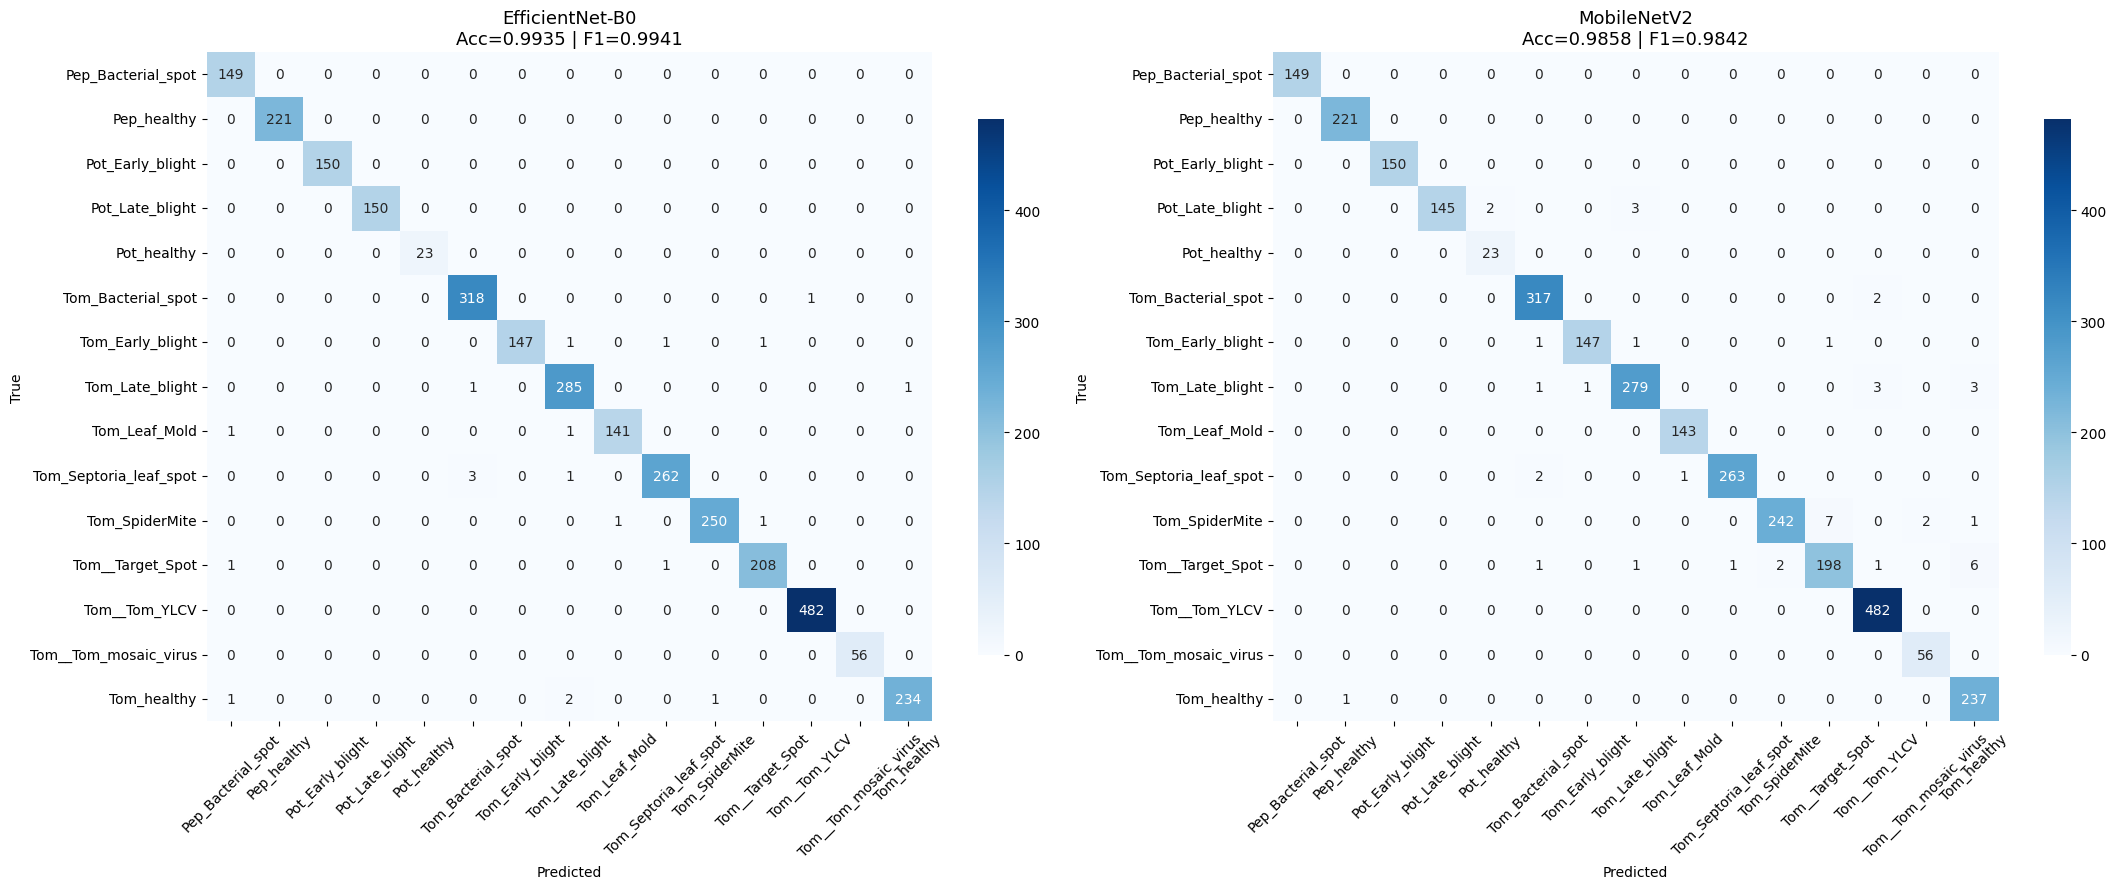

✅ Saved confusion_matrices_comparison.png


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Short labels for readability
short_names = [c.replace("Tomato_", "Tom_").replace("Pepper__bell___", "Pep_")
                .replace("Potato___", "Pot_").replace("Spider_mites_Two_spotted_spider_mite", "SpiderMite")
                .replace("Tomato__", "Tom_").replace("YellowLeaf__Curl_Virus", "YLCV")
                .replace("Tomato_mosaic_virus", "MosaicV")
               for c in class_names]

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, results, name in [
    (axes[0], eff_results, "EfficientNet-B0"),
    (axes[1], mob_results, "MobileNetV2")
]:
    sns.heatmap(results["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=short_names, yticklabels=short_names, ax=ax,
                cbar_kws={"shrink": 0.8})
    ax.set_title(f"{name}\nAcc={results['acc']:.4f} | F1={results['f1_macro']:.4f}", fontsize=13)
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig("confusion_matrices_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved confusion_matrices_comparison.png")

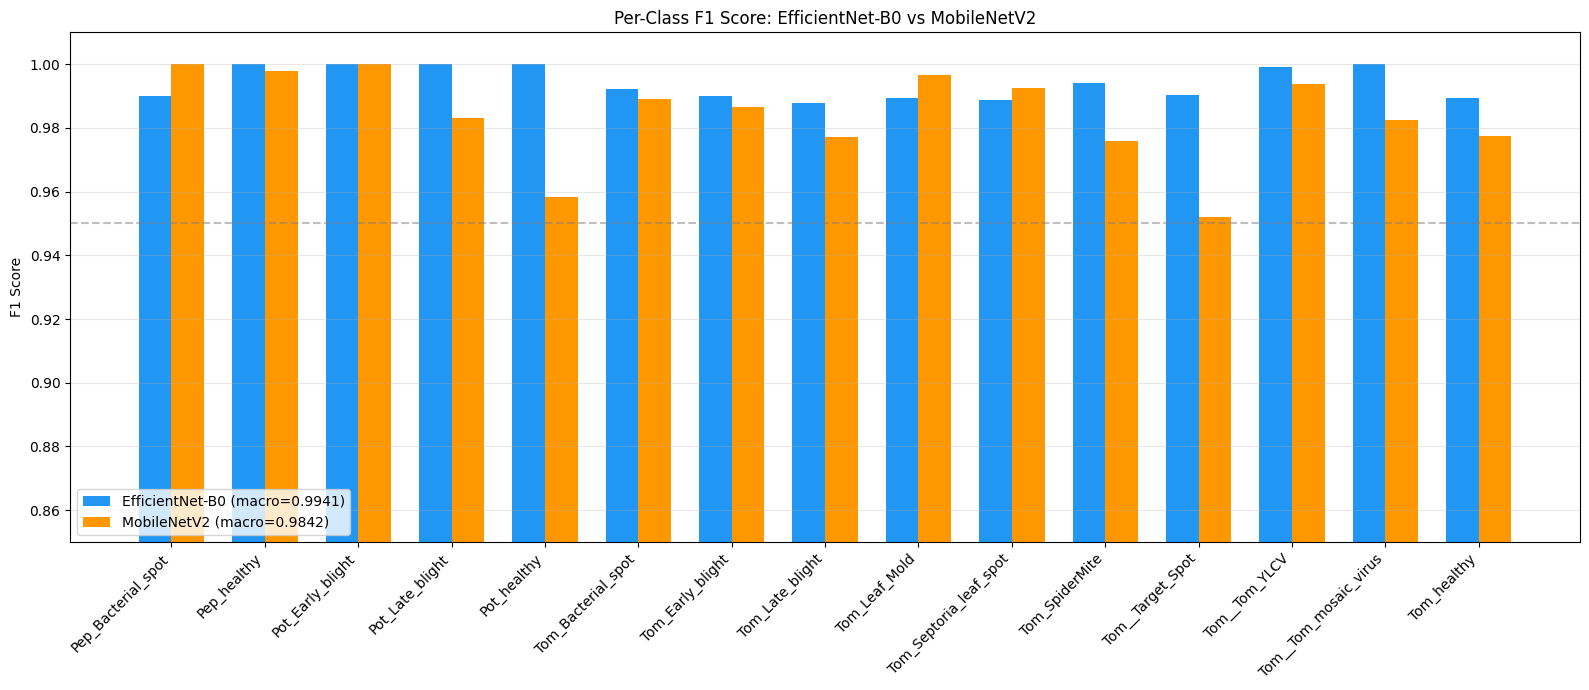

✅ Saved f1_comparison_per_class.png


In [18]:
from sklearn.metrics import f1_score as f1_per

# Per-class F1 for both models
eff_f1_per_class = f1_score(eff_results["labels"], eff_results["preds"], average=None)
mob_f1_per_class = f1_score(mob_results["labels"], mob_results["preds"], average=None)

x = np.arange(NUM_CLASSES)
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar(x - width/2, eff_f1_per_class, width, label=f'EfficientNet-B0 (macro={eff_results["f1_macro"]:.4f})', color='#2196F3')
bars2 = ax.bar(x + width/2, mob_f1_per_class, width, label=f'MobileNetV2 (macro={mob_results["f1_macro"]:.4f})', color='#FF9800')

ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score: EfficientNet-B0 vs MobileNetV2')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.legend(loc='lower left')
ax.set_ylim(0.85, 1.01)
ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5, label='0.95 threshold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("f1_comparison_per_class.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved f1_comparison_per_class.png")

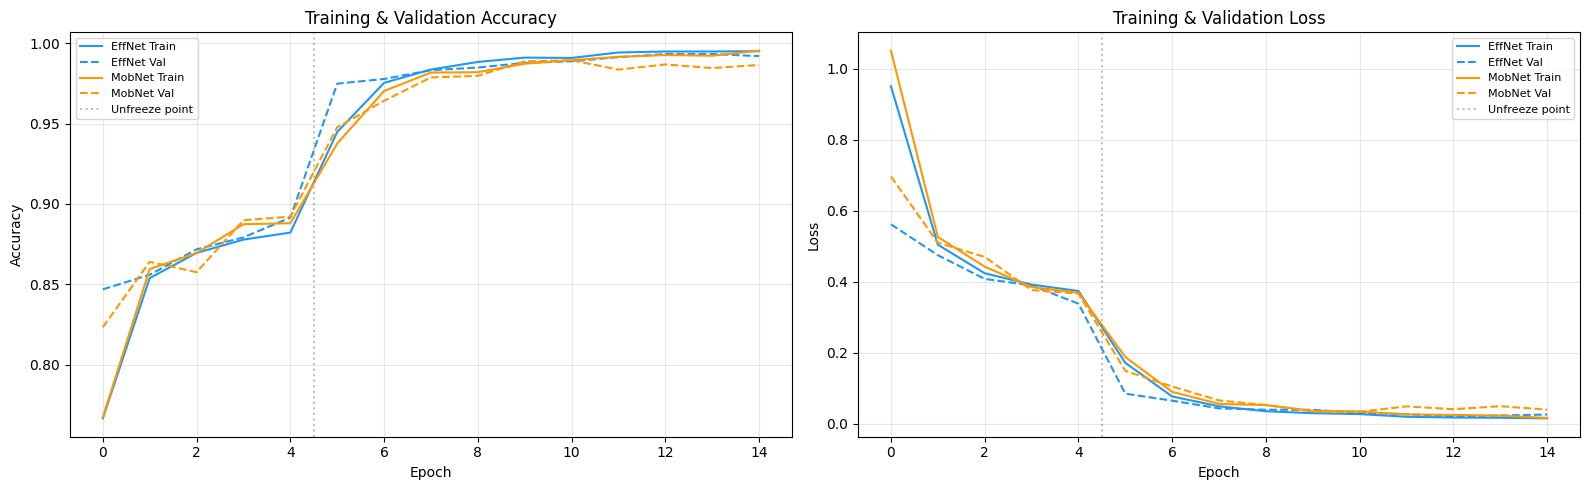

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, ylabel in [(axes[0], "acc", "Accuracy"), (axes[1], "loss", "Loss")]:
    ax.plot(eff_history[f"train_{metric}"], label="EffNet Train", color='#2196F3', linestyle='-')
    ax.plot(eff_history[f"val_{metric}"],   label="EffNet Val",   color='#2196F3', linestyle='--')
    ax.plot(mob_history[f"train_{metric}"], label="MobNet Train", color='#FF9800', linestyle='-')
    ax.plot(mob_history[f"val_{metric}"],   label="MobNet Val",   color='#FF9800', linestyle='--')
    ax.axvline(x=4.5, color='gray', linestyle=':', alpha=0.5, label='Unfreeze point')
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Training & Validation {ylabel}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [20]:
import pandas as pd

summary = pd.DataFrame({
    "Metric": ["Test Accuracy", "F1 (Macro)", "F1 (Weighted)", 
               "Total Params", "Model Size (MB)", "Avg Epoch Time (s)",
               "Best Val Acc"],
    "EfficientNet-B0": [
        f"{eff_results['acc']:.4f}",
        f"{eff_results['f1_macro']:.4f}",
        f"{eff_results['f1_weighted']:.4f}",
        "4.03M",
        f"{os.path.getsize('efficientnet_b0_cropscan.pth') / 1e6:.1f}",
        f"{np.mean(eff_history['epoch_time']):.1f}",
        f"{eff_best:.4f}"
    ],
    "MobileNetV2": [
        f"{mob_results['acc']:.4f}",
        f"{mob_results['f1_macro']:.4f}",
        f"{mob_results['f1_weighted']:.4f}",
        "2.24M",
        f"{os.path.getsize('mobilenetv2_cropscan.pth') / 1e6:.1f}",
        f"{np.mean(mob_history['epoch_time']):.1f}",
        f"{mob_best:.4f}"
    ]
})

print("\n" + "="*65)
print("  FINAL MODEL COMPARISON")
print("="*65)
print(summary.to_string(index=False))
print("="*65)

winner = "EfficientNet-B0" if eff_results['f1_macro'] >= mob_results['f1_macro'] else "MobileNetV2"
margin = abs(eff_results['f1_macro'] - mob_results['f1_macro'])
print(f"\n🏆 {winner} wins by {margin:.4f} F1 (macro)")
print(f"   Both models saved — ready for dual-model V1 backend")


  FINAL MODEL COMPARISON
            Metric EfficientNet-B0 MobileNetV2
     Test Accuracy          0.9935      0.9858
        F1 (Macro)          0.9941      0.9842
     F1 (Weighted)          0.9935      0.9858
      Total Params           4.03M       2.24M
   Model Size (MB)            16.4         9.2
Avg Epoch Time (s)            25.3        25.3
      Best Val Acc          0.9932      0.9893

🏆 EfficientNet-B0 wins by 0.0099 F1 (macro)
   Both models saved — ready for dual-model V1 backend


In [21]:
from PIL import Image

# Class metadata for clean output
CLASS_NAMES = full_dataset.classes
CROP_MAP = {}
for c in CLASS_NAMES:
    if c.startswith("Pepper"):
        CROP_MAP[c] = "Pepper (Bell)"
    elif c.startswith("Potato"):
        CROP_MAP[c] = "Potato"
    else:
        CROP_MAP[c] = "Tomato"

def predict_single(image_path, model, model_name, transform, top_k=3):
    """
    Predict disease from a single leaf image.
    Returns dict ready for JSON API response.
    """
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
    
    top_probs, top_idxs = probs.topk(top_k)
    
    predictions = []
    for prob, idx in zip(top_probs.cpu().numpy(), top_idxs.cpu().numpy()):
        class_name = CLASS_NAMES[idx]
        is_healthy = "healthy" in class_name.lower()
        
        # Clean up the disease name for display
        display_name = class_name.replace("_", " ").replace("  ", " — ", 1)
        
        predictions.append({
            "class": class_name,
            "display_name": display_name,
            "crop": CROP_MAP[class_name],
            "confidence": float(prob),
            "is_healthy": is_healthy
        })
    
    top = predictions[0]
    confident = top["confidence"] >= 0.70  # your threshold from the proposal
    
    result = {
        "model": model_name,
        "top_prediction": top,
        "confident": confident,
        "top_k": predictions,
    }
    
    return result

print("✅ predict_single() ready")

✅ predict_single() ready


In [22]:
def compare_models(image_path):
    """Run both models on one image, print side-by-side results."""
    
    # Show the image
    img = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Input Leaf Image")
    plt.show()
    
    # Run both models
    eff_result = predict_single(image_path, eff_model, "EfficientNet-B0", val_transform)
    mob_result = predict_single(image_path, mob_model, "MobileNetV2", val_transform)
    
    for result in [eff_result, mob_result]:
        top = result["top_prediction"]
        status = "✅ CONFIDENT" if result["confident"] else "⚠️ LOW CONFIDENCE"
        health = "🌿 Healthy" if top["is_healthy"] else "🔴 Disease Detected"
        
        print(f"\n{'─'*50}")
        print(f"  {result['model']}  |  {status}")
        print(f"{'─'*50}")
        print(f"  {health}")
        print(f"  Crop:       {top['crop']}")
        print(f"  Diagnosis:  {top['display_name']}")
        print(f"  Confidence: {top['confidence']:.1%}")
        print(f"\n  Top-3 predictions:")
        for i, p in enumerate(result["top_k"]):
            bar = "█" * int(p["confidence"] * 30)
            print(f"    {i+1}. {p['display_name']:<45} {p['confidence']:.2%}  {bar}")
    
    # Agreement check
    agree = eff_result["top_prediction"]["class"] == mob_result["top_prediction"]["class"]
    print(f"\n{'='*50}")
    print(f"  Models {'AGREE ✅' if agree else 'DISAGREE ⚠️'} on top prediction")
    if not agree:
        print(f"    EfficientNet: {eff_result['top_prediction']['display_name']}")
        print(f"    MobileNetV2:  {mob_result['top_prediction']['display_name']}")
    print(f"{'='*50}")
    
    return eff_result, mob_result

print("✅ compare_models() ready")

✅ compare_models() ready


Ground truth: Tomato_Late_blight
File: PlantVillage_clean/Tomato_Late_blight/a0f74b23-b001-4cb9-8a79-f80bda4cc8e8___GHLB2 Leaf 9018.JPG



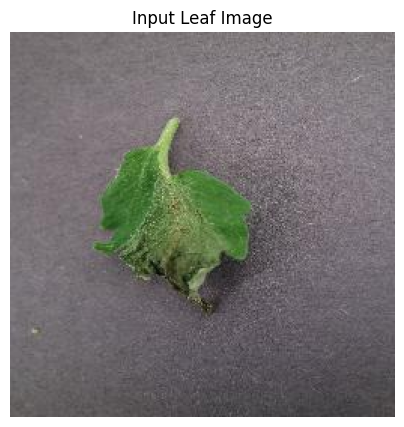


──────────────────────────────────────────────────
  EfficientNet-B0  |  ✅ CONFIDENT
──────────────────────────────────────────────────
  🔴 Disease Detected
  Crop:       Tomato
  Diagnosis:  Tomato Late blight
  Confidence: 100.0%

  Top-3 predictions:
    1. Tomato Late blight                            100.00%  █████████████████████████████
    2. Potato —  Late blight                         0.00%  
    3. Tomato Early blight                           0.00%  

──────────────────────────────────────────────────
  MobileNetV2  |  ✅ CONFIDENT
──────────────────────────────────────────────────
  🔴 Disease Detected
  Crop:       Tomato
  Diagnosis:  Tomato Late blight
  Confidence: 97.6%

  Top-3 predictions:
    1. Tomato Late blight                            97.59%  █████████████████████████████
    2. Tomato healthy                                2.40%  
    3. Tomato — Target Spot                          0.00%  

  Models AGREE ✅ on top prediction


In [23]:
# Grab one random image from the test set
import random

random.seed(42)
sample_idx = random.choice(test_idx)
sample_path, sample_label = full_dataset.samples[sample_idx]

print(f"Ground truth: {CLASS_NAMES[sample_label]}")
print(f"File: {sample_path}\n")

eff_r, mob_r = compare_models(sample_path)

Running on 3 random test images:


🔎 Ground truth: Tomato_Late_blight


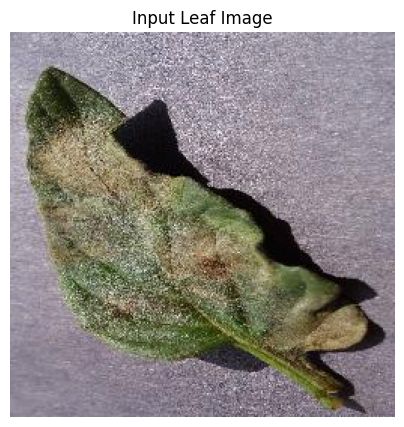


──────────────────────────────────────────────────
  EfficientNet-B0  |  ✅ CONFIDENT
──────────────────────────────────────────────────
  🔴 Disease Detected
  Crop:       Tomato
  Diagnosis:  Tomato Late blight
  Confidence: 85.9%

  Top-3 predictions:
    1. Tomato Late blight                            85.93%  █████████████████████████
    2. Potato —  Late blight                         13.97%  ████
    3. Pepper — bell   Bacterial spot                0.10%  

──────────────────────────────────────────────────
  MobileNetV2  |  ✅ CONFIDENT
──────────────────────────────────────────────────
  🔴 Disease Detected
  Crop:       Tomato
  Diagnosis:  Tomato Late blight
  Confidence: 99.7%

  Top-3 predictions:
    1. Tomato Late blight                            99.74%  █████████████████████████████
    2. Tomato Leaf Mold                              0.19%  
    3. Tomato healthy                                0.03%  

  Models AGREE ✅ on top prediction

════════════════════════════════

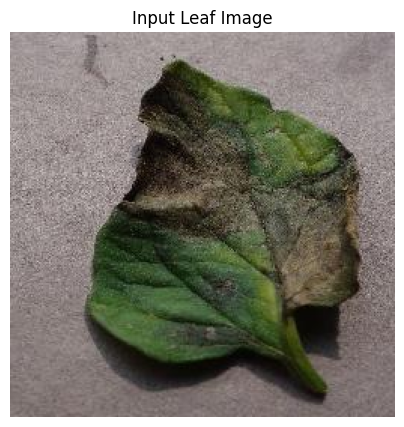


──────────────────────────────────────────────────
  EfficientNet-B0  |  ✅ CONFIDENT
──────────────────────────────────────────────────
  🔴 Disease Detected
  Crop:       Tomato
  Diagnosis:  Tomato Late blight
  Confidence: 100.0%

  Top-3 predictions:
    1. Tomato Late blight                            100.00%  █████████████████████████████
    2. Potato —  Late blight                         0.00%  
    3. Tomato Early blight                           0.00%  

──────────────────────────────────────────────────
  MobileNetV2  |  ✅ CONFIDENT
──────────────────────────────────────────────────
  🔴 Disease Detected
  Crop:       Tomato
  Diagnosis:  Tomato Late blight
  Confidence: 99.8%

  Top-3 predictions:
    1. Tomato Late blight                            99.79%  █████████████████████████████
    2. Potato —  Late blight                         0.20%  
    3. Tomato Early blight                           0.01%  

  Models AGREE ✅ on top prediction

═══════════════════════════════

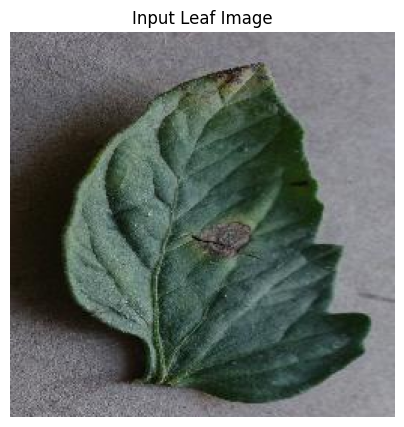


──────────────────────────────────────────────────
  EfficientNet-B0  |  ✅ CONFIDENT
──────────────────────────────────────────────────
  🔴 Disease Detected
  Crop:       Tomato
  Diagnosis:  Tomato Early blight
  Confidence: 100.0%

  Top-3 predictions:
    1. Tomato Early blight                           100.00%  █████████████████████████████
    2. Tomato Late blight                            0.00%  
    3. Tomato Bacterial spot                         0.00%  

──────────────────────────────────────────────────
  MobileNetV2  |  ✅ CONFIDENT
──────────────────────────────────────────────────
  🔴 Disease Detected
  Crop:       Tomato
  Diagnosis:  Tomato Early blight
  Confidence: 100.0%

  Top-3 predictions:
    1. Tomato Early blight                           99.99%  █████████████████████████████
    2. Tomato Late blight                            0.01%  
    3. Tomato Bacterial spot                         0.00%  

  Models AGREE ✅ on top prediction

════════════════════════════

In [24]:
# For Kaggle notebooks:
# from kaggle_secrets import UserSecretsClient  # if needed

# For Colab:
# from google.colab import files
# uploaded = files.upload()
# image_path = list(uploaded.keys())[0]

# For Kaggle — use the file upload widget or put an image in your working directory
# Then just call:
# compare_models("your_leaf_photo.jpg")

# Quick demo — test on a few random test images
print("Running on 3 random test images:\n")
for _ in range(3):
    idx = random.choice(test_idx)
    path, label = full_dataset.samples[idx]
    print(f"\n🔎 Ground truth: {CLASS_NAMES[label]}")
    compare_models(path)
    print("\n" + "═"*60 + "\n")